In [ ]:
# DATA MASTERS CHALLENGE 2026
# Task 1: Data Cleaning & Preprocessing

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

print("Libraries loaded.")

Libraries loaded.


In [ ]:
uploaded = files.upload()

# Load dataset
file_name = list(uploaded.keys())[0]
df_raw = pd.read_csv(file_name)

df = df_raw.copy()

print("Dataset loaded.")
print("Shape:", df.shape)
display(df.head())

Saving milan_cortina_2026_athletes.csv to milan_cortina_2026_athletes.csv
Dataset loaded.
Shape: (390, 17)


,Athlete_ID,Athlete_Name,Country,Gender,Age,Sport,Previous_Olympics,Training_Hours_Per_Week,Altitude_Training_m,Body_Fat_Pct,VO2max,Reaction_Time_ms,Career_Injuries,World_Cup_Points_Preseason,Country_GDP_per_capita,Winter_Sport_Tradition_Index,Medal
0,MC26_1001,Ben Ogden,USA,M,26,Cross-Country,1,35.6,1687.0,NaN,91.5,NaN,1,356.0,80000,0.82,Silver
1,MC26_1002,Loic Meillard,SUI,M,30,Alpine Skiing,3,22.9,2289.0,13.9,71.4,208.0,1,977.0,93000,0.93,Gold
2,MC26_1003,Francesca Lollobrigida,ITA,F,35,Speed Skating,1,29.0,394.0,10.1,82.6,189.0,3,416.0,38000,0.82,Gold
3,MC26_1004,Maria Nilsson,FRA,F,43,Ski Jumping,4,26.2,1239.0,9.1,59.3,183.0,2,801.0,48000,0.87,NaN
4,MC26_1005,Nils Lewis,GER,M,20,Short Track,0,20.2,67.0,12.3,63.1,187.0,2,393.0,52000,0.88,NaN


In [ ]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nBasic info:")
display(df.describe(include="all").T)

Column names:
['Athlete_ID', 'Athlete_Name', 'Country', 'Gender', 'Age', 'Sport', 'Previous_Olympics', 'Training_Hours_Per_Week', 'Altitude_Training_m', 'Body_Fat_Pct', 'VO2max', 'Reaction_Time_ms', 'Career_Injuries', 'World_Cup_Points_Preseason', 'Country_GDP_per_capita', 'Winter_Sport_Tradition_Index', 'Medal']

Data types:


,0
Athlete_ID,object
Athlete_Name,object
Country,object
Gender,object
Age,int64
Sport,object
Previous_Olympics,int64
Training_Hours_Per_Week,float64
Altitude_Training_m,float64
Body_Fat_Pct,float64



Basic info:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Athlete_ID,390,390,MC26_1390,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Athlete_Name,390,369,Emily Taylor,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,390,23,CAN,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,390,2,F,201,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,390.0,NaN,NaN,NaN,31.166667,7.145237,9.0,25.25,31.0,37.0,47.0
Sport,390,14,Alpine Skiing,60,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Previous_Olympics,390.0,NaN,NaN,NaN,2.246154,1.4344,0.0,1.0,2.0,3.0,5.0
Training_Hours_Per_Week,363.0,NaN,NaN,NaN,25.985124,9.207407,13.0,21.7,25.2,29.0,172.0
Altitude_Training_m,366.0,NaN,NaN,NaN,1118.756831,827.076931,1.0,182.0,1344.5,1835.0,2582.0
Body_Fat_Pct,359.0,NaN,NaN,NaN,12.037047,5.355902,6.5,9.8,11.6,13.35,99.2


In [ ]:
# Missing value summary
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2),
    "non_missing_count": df.notna().sum(),
    "dtype": df.dtypes
}).sort_values("missing_percent", ascending=False)

display(missing_summary)

# Save for report
missing_summary.to_csv("01_missing_value_summary_raw.csv")

,missing_count,missing_percent,non_missing_count,dtype
Medal,286,73.33,104,object
Reaction_Time_ms,102,26.15,288,float64
World_Cup_Points_Preseason,98,25.13,292,float64
Body_Fat_Pct,31,7.95,359,float64
VO2max,28,7.18,362,float64
Training_Hours_Per_Week,27,6.92,363,float64
Altitude_Training_m,24,6.15,366,float64
Athlete_ID,0,0.00,390,object
Athlete_Name,0,0.00,390,object
Sport,0,0.00,390,object


In [ ]:
categorical_cols = ["Country", "Gender", "Sport", "Medal"]

for col in categorical_cols:
    print(f"\n===== {col} =====")
    display(df[col].value_counts(dropna=False))


===== Country =====


,count
Country,
CAN,48
USA,46
SWE,31
GER,24
NOR,24
ITA,23
FRA,19
CHN,19
CZE,17



===== Gender =====


,count
Gender,
F,201
M,189



===== Sport =====


,count
Sport,
Alpine Skiing,60
Speed Skating,48
Ice Hockey,48
Cross-Country,43
Biathlon,39
Short Track,30
Freestyle Skiing,30
Snowboard,30
Curling,15



===== Medal =====


,count
Medal,
NaN,286
Gold,49
Silver,32
Bronze,23


In [ ]:
# Remove accidental leading/trailing spaces in text columns
text_cols = df.select_dtypes(include="object").columns

for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

# Convert "nan" strings created by astype(str) back to real NaN for Medal if needed
df["Medal"] = df["Medal"].replace({"nan": np.nan})

print("Text columns standardized.")

Text columns standardized.


In [ ]:
# Medal is the target variable.
# NaN in Medal means the athlete did not win a medal.
df["Medal_Clean"] = df["Medal"].fillna("None")

# Binary target for Task 3
df["Medal_Binary"] = np.where(df["Medal_Clean"] == "None", 0, 1)

# Gold target can be useful for EDA
df["Gold_Binary"] = np.where(df["Medal_Clean"] == "Gold", 1, 0)

display(df[["Medal", "Medal_Clean", "Medal_Binary", "Gold_Binary"]].head(10))

print(df["Medal_Clean"].value_counts())
print("\nMedalist rate:", round(df["Medal_Binary"].mean() * 100, 2), "%")

,Medal,Medal_Clean,Medal_Binary,Gold_Binary
0,Silver,Silver,1,0
1,Gold,Gold,1,1
2,Gold,Gold,1,1
3,NaN,None,0,0
4,NaN,None,0,0
5,NaN,None,0,0
6,NaN,None,0,0
7,NaN,None,0,0
8,NaN,None,0,0
9,NaN,None,0,0


Medal_Clean
None      286
Gold       49
Silver     32
Bronze     23
Name: count, dtype: int64

Medalist rate: 26.67 %


In [ ]:
duplicate_check_cols = [col for col in df.columns if col not in ["Athlete_ID"]]

duplicate_rows = df[df.duplicated(subset=duplicate_check_cols, keep=False)].sort_values(
    ["Athlete_Name", "Country", "Sport"]
)

print("Number of duplicate rows including both original and repeated copies:", duplicate_rows.shape[0])
display(duplicate_rows)

# Save duplicate audit table
duplicate_rows.to_csv("02_duplicate_records_detected.csv", index=False)

Number of duplicate rows including both original and repeated copies: 6


,Athlete_ID,Athlete_Name,Country,Gender,Age,Sport,Previous_Olympics,Training_Hours_Per_Week,Altitude_Training_m,Body_Fat_Pct,VO2max,Reaction_Time_ms,Career_Injuries,World_Cup_Points_Preseason,Country_GDP_per_capita,Winter_Sport_Tradition_Index,Medal,Medal_Clean,Medal_Binary,Gold_Binary
131,MC26_1132,Brandon Bernard,CHN,M,42,Ice Hockey,2,22.5,155.0,12.0,61.9,165.0,1,NaN,13000,0.62,NaN,None,0,0
274,MC26_1275,Brandon Bernard,CHN,M,42,Ice Hockey,2,22.5,155.0,12.0,61.9,165.0,1,NaN,13000,0.62,NaN,None,0,0
128,MC26_1129,Lisa Martin,JPN,F,24,Alpine Skiing,2,26.2,1835.0,9.2,63.8,177.0,3,745.0,35000,0.74,NaN,None,0,0
382,MC26_1383,Lisa Martin,JPN,F,24,Alpine Skiing,2,26.2,1835.0,9.2,63.8,177.0,3,745.0,35000,0.74,NaN,None,0,0
275,MC26_1276,Trevor Martin,FRA,M,37,Ice Hockey,1,23.2,NaN,14.6,NaN,219.0,5,NaN,48000,0.87,NaN,None,0,0
355,MC26_1356,Trevor Martin,FRA,M,37,Ice Hockey,1,23.2,NaN,14.6,NaN,219.0,5,NaN,48000,0.87,NaN,None,0,0


In [ ]:
before_duplicate_shape = df.shape

df = df.drop_duplicates(subset=duplicate_check_cols, keep="first").copy()

after_duplicate_shape = df.shape

duplicate_summary = pd.DataFrame({
    "Step": ["Before duplicate removal", "After duplicate removal"],
    "Rows": [before_duplicate_shape[0], after_duplicate_shape[0]],
    "Columns": [before_duplicate_shape[1], after_duplicate_shape[1]]
})

display(duplicate_summary)
duplicate_summary.to_csv("03_duplicate_removal_summary.csv", index=False)

,Step,Rows,Columns
0,Before duplicate removal,390,20
1,After duplicate removal,387,20


In [ ]:
# Define impossible / erroneous rules
error_conditions = {
    "Age": df["Age"] < 15,
    "Training_Hours_Per_Week": df["Training_Hours_Per_Week"] > 80,
    "Body_Fat_Pct": df["Body_Fat_Pct"] > 60,
    "VO2max": df["VO2max"] <= 0
}

error_records = []

for col, condition in error_conditions.items():
    temp = df.loc[condition, [
        "Athlete_ID", "Athlete_Name", "Country", "Gender", "Sport", col
    ]].copy()
    temp["error_column"] = col
    temp["error_value"] = temp[col]
    error_records.append(temp)

error_audit = pd.concat(error_records, ignore_index=True)

display(error_audit)
error_audit.to_csv("04_impossible_values_detected.csv", index=False)

,Athlete_ID,Athlete_Name,Country,Gender,Sport,Age,error_column,error_value,Training_Hours_Per_Week,Body_Fat_Pct,VO2max
0,MC26_1170,Pierre Johnson,GBR,M,Ice Hockey,9.0,Age,9.0,NaN,NaN,NaN
1,MC26_1328,Kyle Thompson,SWE,M,Speed Skating,NaN,Training_Hours_Per_Week,172.0,172.0,NaN,NaN
2,MC26_1176,Jonas Wilson,NED,M,Snowboard,NaN,Body_Fat_Pct,99.2,NaN,99.2,NaN
3,MC26_1010,Nathan Fischer,FIN,M,Short Track,NaN,VO2max,-8.4,NaN,NaN,-8.4


In [ ]:
# Keep original values before fixing for transparency
for col in ["Age", "Training_Hours_Per_Week", "Body_Fat_Pct", "VO2max"]:
    df[col + "_Original"] = df[col]

# Set impossible values to NaN
df.loc[df["Age"] < 15, "Age"] = np.nan
df.loc[df["Training_Hours_Per_Week"] > 80, "Training_Hours_Per_Week"] = np.nan
df.loc[df["Body_Fat_Pct"] > 60, "Body_Fat_Pct"] = np.nan
df.loc[df["VO2max"] <= 0, "VO2max"] = np.nan

# Create flags showing which rows had planted errors
df["Flag_Age_Error"] = df["Age_Original"].lt(15)
df["Flag_Training_Error"] = df["Training_Hours_Per_Week_Original"].gt(80)
df["Flag_BodyFat_Error"] = df["Body_Fat_Pct_Original"].gt(60)
df["Flag_VO2_Error"] = df["VO2max_Original"].le(0)

print("Impossible values set to NaN and flagged.")
display(df.loc[
    df[["Flag_Age_Error", "Flag_Training_Error", "Flag_BodyFat_Error", "Flag_VO2_Error"]].any(axis=1),
    ["Athlete_ID", "Athlete_Name", "Country", "Sport",
     "Age_Original", "Age",
     "Training_Hours_Per_Week_Original", "Training_Hours_Per_Week",
     "Body_Fat_Pct_Original", "Body_Fat_Pct",
     "VO2max_Original", "VO2max",
     "Flag_Age_Error", "Flag_Training_Error", "Flag_BodyFat_Error", "Flag_VO2_Error"]
])

Impossible values set to NaN and flagged.


,Athlete_ID,Athlete_Name,Country,Sport,Age_Original,Age,Training_Hours_Per_Week_Original,Training_Hours_Per_Week,Body_Fat_Pct_Original,Body_Fat_Pct,VO2max_Original,VO2max,Flag_Age_Error,Flag_Training_Error,Flag_BodyFat_Error,Flag_VO2_Error
9,MC26_1010,Nathan Fischer,FIN,Short Track,43,43.0,23.9,23.9,9.0,9.0,-8.4,NaN,False,False,False,True
169,MC26_1170,Pierre Johnson,GBR,Ice Hockey,9,NaN,25.4,25.4,12.4,12.4,63.9,63.9,True,False,False,False
175,MC26_1176,Jonas Wilson,NED,Snowboard,28,28.0,19.8,19.8,99.2,NaN,57.6,57.6,False,False,True,False
327,MC26_1328,Kyle Thompson,SWE,Speed Skating,30,30.0,172.0,NaN,11.2,11.2,79.1,79.1,False,True,False,False


In [ ]:
missing_after_error_fix = pd.DataFrame({
    "missing_count_after_error_fix": df.isna().sum(),
    "missing_percent_after_error_fix": (df.isna().mean() * 100).round(2),
    "dtype": df.dtypes
}).sort_values("missing_percent_after_error_fix", ascending=False)

display(missing_after_error_fix)
missing_after_error_fix.to_csv("05_missing_value_summary_after_error_fix.csv")

,missing_count_after_error_fix,missing_percent_after_error_fix,dtype
Medal,283,73.13,object
Reaction_Time_ms,102,26.36,float64
World_Cup_Points_Preseason,96,24.81,float64
Body_Fat_Pct,32,8.27,float64
Body_Fat_Pct_Original,31,8.01,float64
VO2max,28,7.24,float64
Training_Hours_Per_Week,28,7.24,float64
Training_Hours_Per_Week_Original,27,6.98,float64
VO2max_Original,27,6.98,float64
Altitude_Training_m,23,5.94,float64


In [ ]:
# Missingness flags
missing_flag_cols = [
    "Training_Hours_Per_Week",
    "Altitude_Training_m",
    "Body_Fat_Pct",
    "VO2max",
    "Reaction_Time_ms",
    "World_Cup_Points_Preseason"
]

for col in missing_flag_cols:
    df[f"Missing_{col}"] = df[col].isna().astype(int)

# Explicit MNAR flags
df["MNAR_Reaction_Time_Missing"] = df["Reaction_Time_ms"].isna().astype(int)
df["MNAR_World_Cup_Points_Missing"] = df["World_Cup_Points_Preseason"].isna().astype(int)

print("Missingness flags created.")
display(df[[f"Missing_{col}" for col in missing_flag_cols] +
           ["MNAR_Reaction_Time_Missing", "MNAR_World_Cup_Points_Missing"]].head())

Missingness flags created.


,Missing_Training_Hours_Per_Week,Missing_Altitude_Training_m,Missing_Body_Fat_Pct,Missing_VO2max,Missing_Reaction_Time_ms,Missing_World_Cup_Points_Preseason,MNAR_Reaction_Time_Missing,MNAR_World_Cup_Points_Missing
0,0,0,1,0,1,0,1,0
1,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0


In [ ]:
missing_by_sport = df.groupby("Sport")[missing_flag_cols].apply(lambda x: x.isna().mean() * 100).round(1)

display(missing_by_sport)

missing_by_sport.to_csv("06_missingness_by_sport_percent.csv")

,Training_Hours_Per_Week,Altitude_Training_m,Body_Fat_Pct,VO2max,Reaction_Time_ms,World_Cup_Points_Preseason
Sport,,,,,,
Alpine Skiing,1.7,6.8,5.1,8.5,16.9,8.5
Biathlon,15.4,7.7,7.7,7.7,20.5,17.9
Bobsleigh,14.3,7.1,7.1,0.0,21.4,7.1
Cross-Country,4.7,2.3,4.7,0.0,100.0,4.7
Curling,6.7,6.7,20.0,0.0,100.0,100.0
Figure Skating,0.0,0.0,0.0,0.0,100.0,100.0
Freestyle Skiing,10.0,3.3,13.3,6.7,3.3,10.0
Ice Hockey,8.7,6.5,4.3,8.7,6.5,100.0
Luge,0.0,0.0,8.3,0.0,8.3,16.7


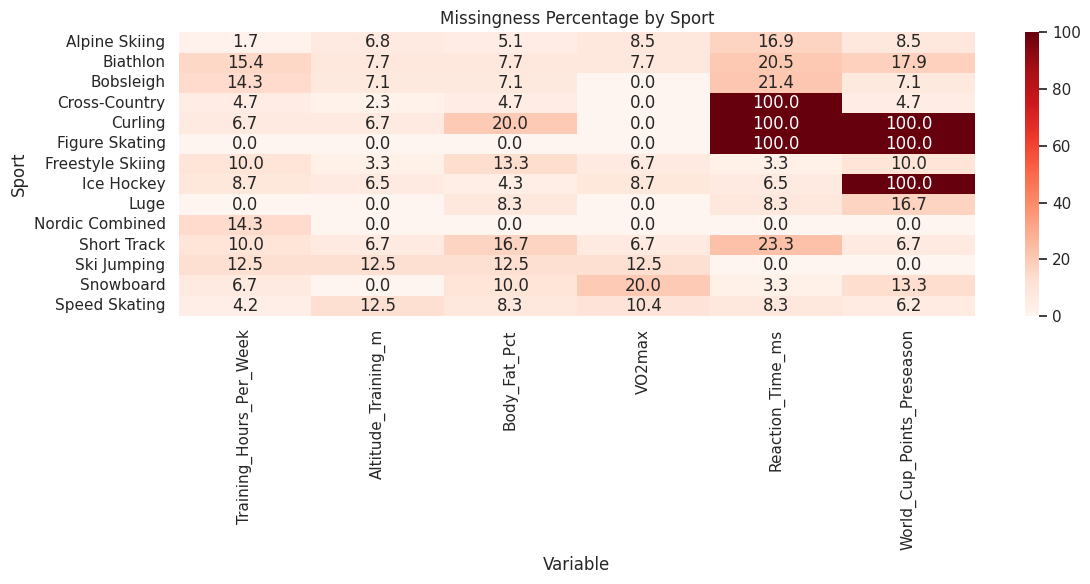

In [ ]:
plt.figure(figsize=(12, 6))
sns.heatmap(missing_by_sport, annot=True, cmap="Reds", fmt=".1f")
plt.title("Missingness Percentage by Sport")
plt.xlabel("Variable")
plt.ylabel("Sport")
plt.tight_layout()
plt.savefig("missingness_by_sport_heatmap.png", dpi=300)
plt.show()

In [ ]:
def impute_by_sport_gender_then_sport_then_global(data, col):
    """
    Impute numeric column using:
    1. Sport + Gender median
    2. Sport median
    3. Global median
    """
    data = data.copy()

    # Sport + gender median
    sg_median = data.groupby(["Sport", "Gender"])[col].transform("median")
    data[col] = data[col].fillna(sg_median)

    # Sport median
    sport_median = data.groupby("Sport")[col].transform("median")
    data[col] = data[col].fillna(sport_median)

    # Global median
    global_median = data[col].median()
    data[col] = data[col].fillna(global_median)

    return data[col]

In [ ]:
numeric_impute_cols = [
    "Age",
    "Training_Hours_Per_Week",
    "Altitude_Training_m",
    "Body_Fat_Pct",
    "VO2max",
    "Reaction_Time_ms",
    "World_Cup_Points_Preseason"
]

# Create imputation audit table before imputation
imputation_audit = []

for col in numeric_impute_cols:
    before_missing = df[col].isna().sum()
    df[col] = impute_by_sport_gender_then_sport_then_global(df, col)
    after_missing = df[col].isna().sum()

    imputation_audit.append({
        "variable": col,
        "missing_before_imputation": before_missing,
        "missing_after_imputation": after_missing,
        "method": "Sport + Gender median, then Sport median, then Global median"
    })

imputation_audit = pd.DataFrame(imputation_audit)
display(imputation_audit)

imputation_audit.to_csv("07_imputation_audit.csv", index=False)

,variable,missing_before_imputation,missing_after_imputation,method
0,Age,1,0,"Sport + Gender median, then Sport median, then..."
1,Training_Hours_Per_Week,28,0,"Sport + Gender median, then Sport median, then..."
2,Altitude_Training_m,23,0,"Sport + Gender median, then Sport median, then..."
3,Body_Fat_Pct,32,0,"Sport + Gender median, then Sport median, then..."
4,VO2max,28,0,"Sport + Gender median, then Sport median, then..."
5,Reaction_Time_ms,102,0,"Sport + Gender median, then Sport median, then..."
6,World_Cup_Points_Preseason,96,0,"Sport + Gender median, then Sport median, then..."


In [ ]:
clean_missing_summary = pd.DataFrame({
    "missing_count_cleaned": df.isna().sum(),
    "missing_percent_cleaned": (df.isna().mean() * 100).round(2),
    "dtype": df.dtypes
}).sort_values("missing_percent_cleaned", ascending=False)

display(clean_missing_summary)
clean_missing_summary.to_csv("08_missing_value_summary_cleaned.csv")

,missing_count_cleaned,missing_percent_cleaned,dtype
Medal,283,73.13,object
Body_Fat_Pct_Original,31,8.01,float64
VO2max_Original,27,6.98,float64
Training_Hours_Per_Week_Original,27,6.98,float64
Gender,0,0.00,object
Country,0,0.00,object
Athlete_Name,0,0.00,object
Athlete_ID,0,0.00,object
Altitude_Training_m,0,0.00,float64
Age,0,0.00,float64


In [ ]:
outlier_numeric_cols = [
    "Age",
    "Previous_Olympics",
    "Training_Hours_Per_Week",
    "Altitude_Training_m",
    "Body_Fat_Pct",
    "VO2max",
    "Reaction_Time_ms",
    "Career_Injuries",
    "World_Cup_Points_Preseason",
    "Country_GDP_per_capita",
    "Winter_Sport_Tradition_Index"
]

outlier_summary = []

for col in outlier_numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    flag_col = f"Outlier_IQR_{col}"
    df[flag_col] = ((df[col] < lower) | (df[col] > upper)).astype(int)

    outlier_summary.append({
        "variable": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": df[flag_col].sum(),
        "outlier_percent": round(df[flag_col].mean() * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary)
display(outlier_summary)

outlier_summary.to_csv("09_outlier_summary_iqr.csv", index=False)

,variable,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percent
0,Age,26.00,37.00,11.00,9.500,53.500,0,0.00
1,Previous_Olympics,1.00,3.00,2.00,-2.000,6.000,0,0.00
2,Training_Hours_Per_Week,21.70,29.00,7.30,10.750,39.950,0,0.00
3,Altitude_Training_m,174.50,1832.00,1657.50,-2311.750,4318.250,0,0.00
4,Body_Fat_Pct,9.90,13.20,3.30,4.950,18.150,14,3.62
5,VO2max,61.15,76.50,15.35,38.125,99.525,0,0.00
6,Reaction_Time_ms,177.00,204.00,27.00,136.500,244.500,15,3.88
7,Career_Injuries,1.00,4.00,3.00,-3.500,8.500,0,0.00
8,World_Cup_Points_Preseason,399.50,730.00,330.50,-96.250,1225.750,7,1.81
9,Country_GDP_per_capita,38000.00,62000.00,24000.00,2000.000,98000.000,0,0.00


In [ ]:
# Show age outliers or notable older/younger athletes
important_age_cases = df[
    (df["Age"] <= 20) | (df["Age"] >= 40)
][[
    "Athlete_ID", "Athlete_Name", "Country", "Gender", "Sport",
    "Age", "Previous_Olympics", "Medal_Clean"
]].sort_values("Age")

display(important_age_cases)

important_age_cases.to_csv("10_important_age_cases.csv", index=False)

,Athlete_ID,Athlete_Name,Country,Gender,Sport,Age,Previous_Olympics,Medal_Clean
45,MC26_1046,Choi Gaon,KOR,F,Snowboard,19.0,3,Gold
194,MC26_1195,Viktor Muller,KOR,M,Speed Skating,19.0,3,None
177,MC26_1178,Dylan Campbell,POL,M,Biathlon,19.0,3,None
158,MC26_1159,Sofia Keller,SWE,F,Cross-Country,19.0,1,Gold
252,MC26_1253,Rachel Jackson,CAN,F,Speed Skating,19.0,3,None
379,MC26_1380,Andrew Harris,NOR,M,Freestyle Skiing,19.0,0,None
346,MC26_1347,Brandon Thompson,CAN,M,Freestyle Skiing,19.0,1,Bronze
367,MC26_1368,Nina Schmidt,CZE,F,Speed Skating,19.0,4,None
372,MC26_1373,Nicolas Thomas,AUS,M,Speed Skating,19.0,1,None
388,MC26_1389,Maria Murray,AUS,F,Alpine Skiing,19.0,1,None


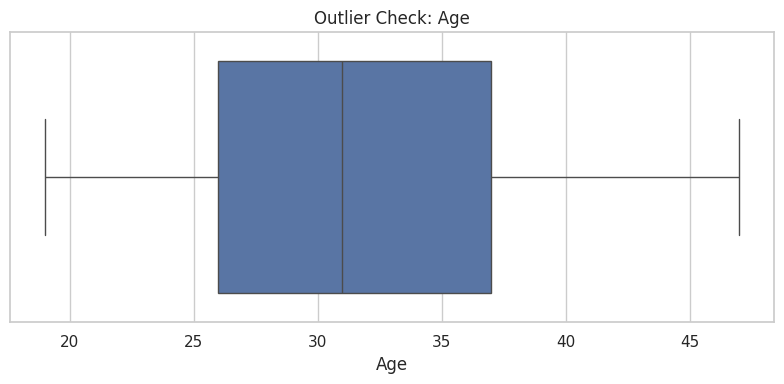

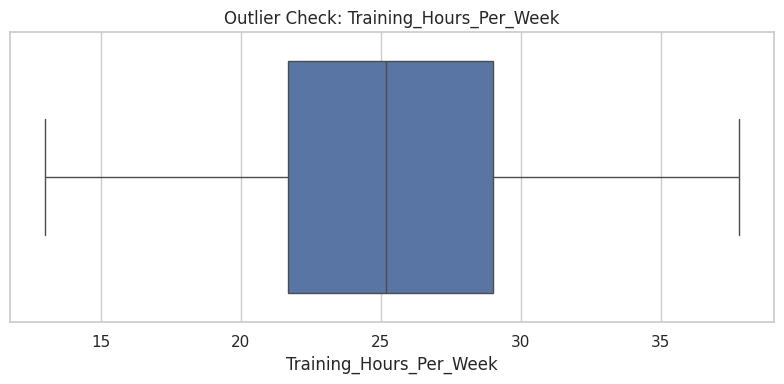

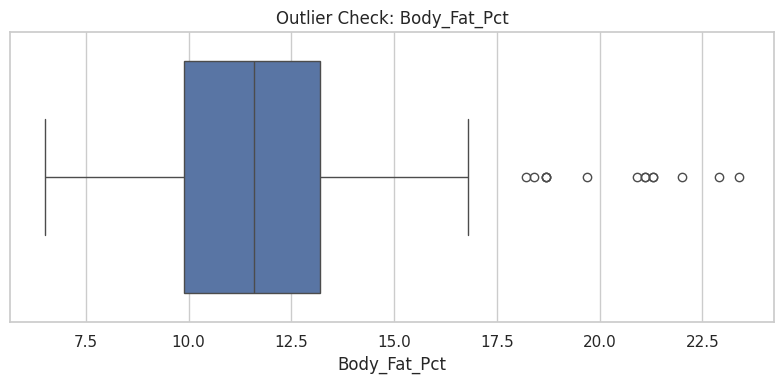

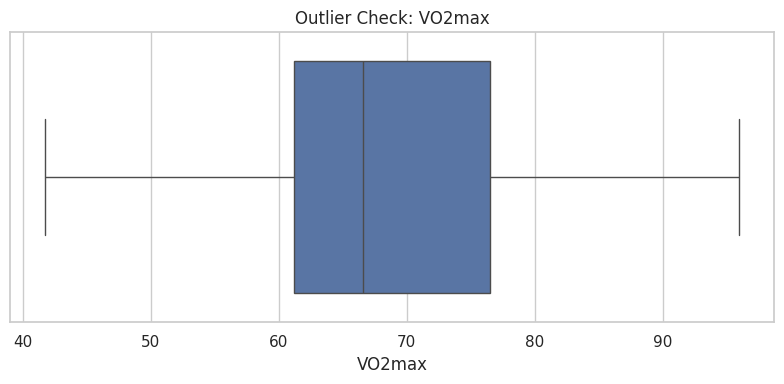

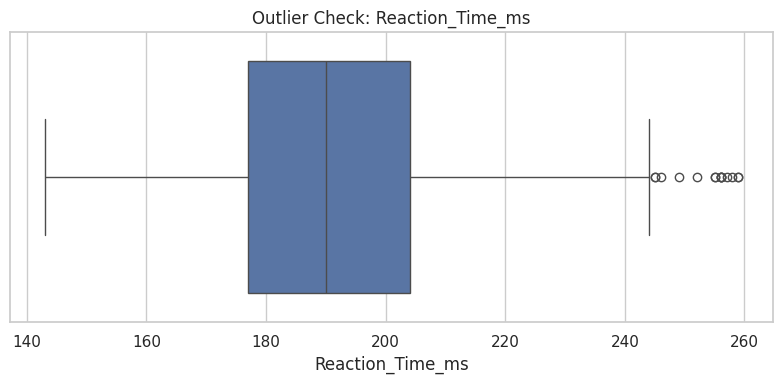

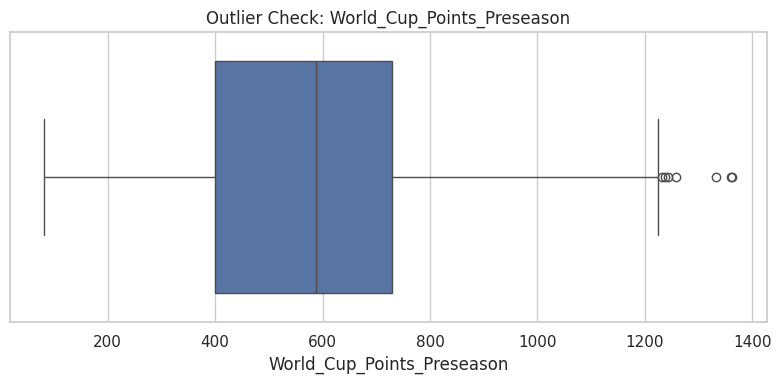

In [ ]:
plot_cols = [
    "Age",
    "Training_Hours_Per_Week",
    "Body_Fat_Pct",
    "VO2max",
    "Reaction_Time_ms",
    "World_Cup_Points_Preseason"
]

for col in plot_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x=col)
    plt.title(f"Outlier Check: {col}")
    plt.tight_layout()
    plt.savefig(f"outlier_boxplot_{col}.png", dpi=300)
    plt.show()

In [ ]:
# Avoid division by zero
df["VO2_BodyFat_Efficiency"] = df["VO2max"] / df["Body_Fat_Pct"]

# Experience × training load
df["Experience_Training_Index"] = df["Previous_Olympics"] * df["Training_Hours_Per_Week"]

# National resource/tradition composite
df["GDP_Tradition_Index"] = df["Country_GDP_per_capita"] * df["Winter_Sport_Tradition_Index"]

# Training load adjusted by injury history
df["Training_Injury_Burden"] = df["Training_Hours_Per_Week"] * (1 + df["Career_Injuries"])

# Age bands for EDA
df["Age_Band"] = pd.cut(
    df["Age"],
    bins=[0, 22, 27, 32, 37, 100],
    labels=["Under 23", "23-27", "28-32", "33-37", "38+"]
)

# Podium grouping for EDA
df["Podium_Group"] = np.select(
    [
        df["Medal_Clean"] == "Gold",
        df["Medal_Clean"].isin(["Silver", "Bronze"]),
        df["Medal_Clean"] == "None"
    ],
    [
        "Gold",
        "Silver/Bronze",
        "No Medal"
    ],
    default="Unknown"
)

# North America flag
df["North_America_Rivalry"] = np.where(df["Country"].isin(["USA", "CAN"]), df["Country"], "Other")

display(df[[
    "Athlete_Name", "Country", "Sport",
    "VO2_BodyFat_Efficiency",
    "Experience_Training_Index",
    "GDP_Tradition_Index",
    "Training_Injury_Burden",
    "Age_Band",
    "Podium_Group",
    "North_America_Rivalry"
]].head())

,Athlete_Name,Country,Sport,VO2_BodyFat_Efficiency,Experience_Training_Index,GDP_Tradition_Index,Training_Injury_Burden,Age_Band,Podium_Group,North_America_Rivalry
0,Ben Ogden,USA,Cross-Country,10.280899,35.6,65600.0,71.2,23-27,Silver/Bronze,USA
1,Loic Meillard,SUI,Alpine Skiing,5.136691,68.7,86490.0,45.8,28-32,Gold,Other
2,Francesca Lollobrigida,ITA,Speed Skating,8.178218,29.0,31160.0,116.0,33-37,Gold,Other
3,Maria Nilsson,FRA,Ski Jumping,6.516484,104.8,41760.0,78.6,38+,No Medal,Other
4,Nils Lewis,GER,Short Track,5.130081,0.0,45760.0,60.6,Under 23,No Medal,Other


In [ ]:
before_after_summary = pd.DataFrame({
    "Stage": [
        "Raw dataset",
        "After duplicate removal",
        "After impossible values set to missing",
        "After imputation and feature engineering"
    ],
    "Rows": [
        df_raw.shape[0],
        after_duplicate_shape[0],
        after_duplicate_shape[0],
        df.shape[0]
    ],
    "Columns": [
        df_raw.shape[1],
        after_duplicate_shape[1],
        after_duplicate_shape[1],
        df.shape[1]
    ],
    "Notes": [
        "Original dataset",
        "Removed duplicate athlete records based on all non-ID fields",
        "Impossible values flagged and replaced with NaN before imputation",
        "Missing numeric values imputed; features and flags added"
    ]
})

display(before_after_summary)

before_after_summary.to_csv("11_before_after_cleaning_summary.csv", index=False)

,Stage,Rows,Columns,Notes
0,Raw dataset,390,17,Original dataset
1,After duplicate removal,387,20,Removed duplicate athlete records based on all...
2,After impossible values set to missing,387,20,Impossible values flagged and replaced with Na...
3,After imputation and feature engineering,387,54,Missing numeric values imputed; features and f...


In [ ]:
cleaning_decision_log = pd.DataFrame({
    "Issue": [
        "Missing Medal values",
        "Duplicate records",
        "Impossible Age",
        "Impossible Training Hours",
        "Impossible Body Fat Percentage",
        "Impossible VO2max",
        "MCAR-style missing numeric variables",
        "MNAR Reaction Time",
        "MNAR World Cup Points",
        "Outliers",
        "Feature engineering"
    ],
    "Decision": [
        "Filled missing Medal as 'None' because missing medal indicates no medal won.",
        "Removed 3 duplicate records using all columns except Athlete_ID.",
        "Set age below 15 to missing, then imputed using sport/gender median.",
        "Set training hours above 80 per week to missing, then imputed using sport/gender median.",
        "Set body fat percentage above 60% to missing, then imputed using sport/gender median.",
        "Set VO2max less than or equal to 0 to missing, then imputed using sport/gender median.",
        "Imputed using sport/gender median, then sport median, then global median.",
        "Preserved missingness flag because missingness is sport-systematic, then imputed for modeling usability.",
        "Preserved missingness flag because missingness is sport-systematic, then imputed for modeling usability.",
        "Flagged using IQR but did not automatically remove real extreme athletes.",
        "Created physiology, experience, national support, injury-load, age band, and medal grouping features."
    ],
    "Reason": [
        "The Medal column is the target outcome, and non-medalists are represented as blank.",
        "Athlete_ID is a row identifier, so duplicates must be detected using substantive athlete fields.",
        "A 9-year-old Olympic athlete is not plausible in this dataset.",
        "172 training hours/week is physically impossible because a week has 168 hours.",
        "99.2% body fat is biologically impossible for an Olympic athlete.",
        "VO2max cannot be negative.",
        "Sport and gender strongly affect physiology and training values.",
        "Reaction time is not measured or relevant in the same way for every sport.",
        "World Cup points are not equally available across all sports.",
        "The instructions warn that real outliers exist and should not be blindly deleted.",
        "These features connect athlete physiology, training, experience, and country-level sport systems."
    ]
})

display(cleaning_decision_log)

cleaning_decision_log.to_csv("12_cleaning_decision_log.csv", index=False)

,Issue,Decision,Reason
0,Missing Medal values,Filled missing Medal as 'None' because missing...,"The Medal column is the target outcome, and no..."
1,Duplicate records,Removed 3 duplicate records using all columns ...,"Athlete_ID is a row identifier, so duplicates ..."
2,Impossible Age,"Set age below 15 to missing, then imputed usin...",A 9-year-old Olympic athlete is not plausible ...
3,Impossible Training Hours,Set training hours above 80 per week to missin...,172 training hours/week is physically impossib...
4,Impossible Body Fat Percentage,"Set body fat percentage above 60% to missing, ...",99.2% body fat is biologically impossible for ...
5,Impossible VO2max,"Set VO2max less than or equal to 0 to missing,...",VO2max cannot be negative.
6,MCAR-style missing numeric variables,"Imputed using sport/gender median, then sport ...",Sport and gender strongly affect physiology an...
7,MNAR Reaction Time,Preserved missingness flag because missingness...,Reaction time is not measured or relevant in t...
8,MNAR World Cup Points,Preserved missingness flag because missingness...,World Cup points are not equally available acr...
9,Outliers,Flagged using IQR but did not automatically re...,The instructions warn that real outliers exist...


In [ ]:
print("Final shape:", df.shape)

print("\nRemaining missing values:")
display(df.isna().sum().sort_values(ascending=False).head(20))

print("\nMedal distribution:")
display(df["Medal_Clean"].value_counts())

print("\nCountry counts:")
display(df["Country"].value_counts().head(10))

print("\nUSA/CAN counts:")
display(df[df["Country"].isin(["USA", "CAN"])]["Country"].value_counts())

print("\nCheck impossible values are gone:")
print("Age < 15:", (df["Age"] < 15).sum())
print("Training hours > 80:", (df["Training_Hours_Per_Week"] > 80).sum())
print("Body fat > 60:", (df["Body_Fat_Pct"] > 60).sum())
print("VO2max <= 0:", (df["VO2max"] <= 0).sum())

Final shape: (387, 54)

Remaining missing values:


,0
Medal,283
Body_Fat_Pct_Original,31
VO2max_Original,27
Training_Hours_Per_Week_Original,27
Country,0
Gender,0
Sport,0
Age,0
Previous_Olympics,0
Training_Hours_Per_Week,0



Medal distribution:


,count
Medal_Clean,
None,283
Gold,49
Silver,32
Bronze,23



Country counts:


,count
Country,
CAN,48
USA,46
SWE,31
GER,24
NOR,24
ITA,23
FRA,18
CHN,18
CZE,17



USA/CAN counts:


,count
Country,
CAN,48
USA,46



Check impossible values are gone:
Age < 15: 0
Training hours > 80: 0
Body fat > 60: 0
VO2max <= 0: 0


In [ ]:
# Save final cleaned dataset
df.to_csv("milan_cortina_2026_cleaned.csv", index=False)

modeling_cols = [
    "Athlete_ID",
    "Athlete_Name",
    "Country",
    "Gender",
    "Age",
    "Age_Band",
    "Sport",
    "Previous_Olympics",
    "Training_Hours_Per_Week",
    "Altitude_Training_m",
    "Body_Fat_Pct",
    "VO2max",
    "Reaction_Time_ms",
    "Career_Injuries",
    "World_Cup_Points_Preseason",
    "Country_GDP_per_capita",
    "Winter_Sport_Tradition_Index",
    "VO2_BodyFat_Efficiency",
    "Experience_Training_Index",
    "GDP_Tradition_Index",
    "Training_Injury_Burden",
    "Missing_Training_Hours_Per_Week",
    "Missing_Altitude_Training_m",
    "Missing_Body_Fat_Pct",
    "Missing_VO2max",
    "Missing_Reaction_Time_ms",
    "Missing_World_Cup_Points_Preseason",
    "MNAR_Reaction_Time_Missing",
    "MNAR_World_Cup_Points_Missing",
    "Medal_Clean",
    "Medal_Binary",
    "Gold_Binary",
    "Podium_Group",
    "North_America_Rivalry"
]

df_modeling_ready = df[modeling_cols].copy()
df_modeling_ready.to_csv("milan_cortina_2026_modeling_ready.csv", index=False)

print("Files saved:")
print("- milan_cortina_2026_cleaned.csv")
print("- milan_cortina_2026_modeling_ready.csv")

Files saved:
- milan_cortina_2026_cleaned.csv
- milan_cortina_2026_modeling_ready.csv


In [ ]:
files.download("milan_cortina_2026_cleaned.csv")
files.download("milan_cortina_2026_modeling_ready.csv")

report_files = [
    "01_missing_value_summary_raw.csv",
    "02_duplicate_records_detected.csv",
    "03_duplicate_removal_summary.csv",
    "04_impossible_values_detected.csv",
    "05_missing_value_summary_after_error_fix.csv",
    "06_missingness_by_sport_percent.csv",
    "07_imputation_audit.csv",
    "08_missing_value_summary_cleaned.csv",
    "09_outlier_summary_iqr.csv",
    "10_important_age_cases.csv",
    "11_before_after_cleaning_summary.csv",
    "12_cleaning_decision_log.csv"
]

for f in report_files:
    files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>